In [1]:
import random
import matplotlib.pyplot as plt


## Step 1: Set the probabilities and durations

In [2]:
probabilities = {
    "permit": {
        "permit_approved_quickly": {
            "probability": 0.70,
            "months": 1
        },
        "permit_delayed": {
            "probability": 0.30,
            "months": 3
        }
    },

    "weather": {
        "permit_approved_quickly": {
            "summer": {
                "probability": 0.80,
                "months": 0
            },
            "winter": {
                "probability": 0.20,
                "months": 2
            }
        },

        "permit_delayed": {
            "summer": {
                "probability": 0.50,
                "months": 0
            },
            "winter": {
                "probability": 0.50,
                "months": 2
            }
        }
    },

    "finishing": {
        "summer": {
            "finish_fast": {
                "probability": 0.75,
                "months": 1
            },
            "finish_slow": {
                "probability": 0.25,
                "months": 2
            }
        },

        "winter": {
            "finish_fast": {
                "probability": 0.40,
                "months": 2
            },
            "finish_slow": {
                "probability": 0.60,
                "months": 4
            }
        }
    }
}

## Step 2: Run one simulation

In [12]:
def run_simulation():

    # Branch 1: Does the permit get approved quickly?

    roll = random.random()
    cumulative = 0

    for permit, outcome in probabilities["permit"].items():
        cumulative += outcome["probability"]
        if roll < cumulative:
            break

    permit_months = probabilities["permit"][permit]["months"]

    # print("Step 1 random roll: ", roll*100)
    # print(f"Permit: {permit}")
    # print(f"Permit months: +{permit_months}")
    # print("---")

    # Branch 2: What is the weather, given how quickly the permit was approved?

    roll = random.random()
    cumulative = 0

    for weather, outcome in probabilities["weather"][permit].items():
        cumulative += outcome["probability"]
        if roll < cumulative:
            break

    weather_months = probabilities["weather"][permit][weather]["months"]

    # print("Step 2 random roll: ", roll*100)
    # print(f"Weather: {weather}")
    # print(f"Weather months: +{weather_months}")
    # print("---")

    # Branch 3: How fast is the finishing work, given the weather?

    roll = random.random()
    cumulative = 0

    for finishing, outcome in probabilities["finishing"][weather].items():
        cumulative += outcome["probability"]
        if roll < cumulative:
            break

    finishing_months = probabilities["finishing"][weather][finishing]["months"]

    # print("Step 3 random roll: ", roll*100)
    # print(f"Finishing: {finishing}")
    # print(f"Finishing months: +{finishing_months}")
    # print("---")

    # Total time is the sum of each phase's duration

    total_months = permit_months + weather_months + finishing_months


    # print(f"Total months: {total_months}")
    # print("---")

    return permit, weather, finishing, total_months

In [11]:
# Run a single simulation

permit, weather, finishing, total_months = run_simulation()



Step 1 random roll:  88.3596088644749
Permit: permit_delayed
Permit months: +3
---
Step 2 random roll:  89.54706913794799
Weather: winter
Weather months: +2
---
Step 3 random roll:  68.37473726915971
Finishing: finish_slow
Finishing months: +4
---
Total months: 9
---


## Step 3: Run the Monte Carlo simulation

In [15]:
num_simulations = 10000
total_months_list = []

for i in range(num_simulations):

    permit, weather, finishing, total_months = run_simulation()

    total_months_list.append(total_months)

print(total_months_list)

[2, 2, 2, 4, 3, 2, 3, 4, 7, 2, 2, 7, 2, 2, 7, 7, 5, 2, 7, 2, 3, 2, 2, 4, 2, 7, 3, 9, 3, 2, 4, 2, 7, 3, 2, 2, 4, 2, 2, 7, 7, 3, 2, 4, 7, 9, 2, 5, 4, 3, 7, 2, 4, 7, 2, 7, 7, 9, 2, 7, 4, 5, 2, 2, 2, 9, 3, 2, 2, 4, 2, 9, 7, 4, 7, 7, 7, 2, 4, 7, 7, 2, 9, 3, 2, 3, 7, 9, 4, 2, 4, 2, 2, 2, 7, 4, 9, 7, 9, 2, 2, 7, 2, 2, 2, 5, 3, 7, 7, 2, 3, 9, 2, 7, 9, 2, 2, 9, 2, 3, 2, 3, 9, 2, 4, 2, 2, 9, 2, 2, 2, 3, 2, 9, 7, 4, 2, 4, 7, 2, 7, 3, 2, 2, 2, 2, 2, 9, 5, 7, 7, 5, 9, 2, 9, 5, 7, 2, 2, 7, 7, 7, 2, 2, 4, 7, 4, 5, 3, 3, 2, 2, 3, 4, 7, 2, 5, 3, 9, 3, 2, 5, 2, 2, 2, 7, 4, 2, 2, 2, 2, 2, 2, 2, 7, 4, 5, 2, 2, 2, 5, 4, 2, 7, 2, 2, 9, 2, 9, 2, 2, 2, 3, 9, 7, 2, 4, 9, 3, 4, 3, 7, 5, 2, 3, 7, 7, 3, 9, 2, 7, 4, 7, 7, 5, 2, 4, 9, 3, 4, 2, 4, 3, 7, 3, 2, 7, 2, 2, 2, 5, 2, 5, 2, 3, 9, 2, 7, 7, 3, 4, 7, 2, 2, 4, 9, 4, 9, 2, 2, 2, 5, 4, 5, 2, 7, 5, 2, 3, 9, 7, 7, 2, 2, 7, 2, 2, 9, 4, 4, 2, 2, 2, 2, 4, 4, 2, 2, 5, 3, 3, 2, 3, 7, 3, 2, 5, 2, 2, 2, 2, 2, 2, 2, 2, 9, 4, 2, 2, 4, 7, 7, 3, 9, 3, 5, 3, 2, 2, 2, 2, 2, 7, 

## Step 4: Calculate & plot the results

Fastest project: 2 months
Slowest project: 9 months


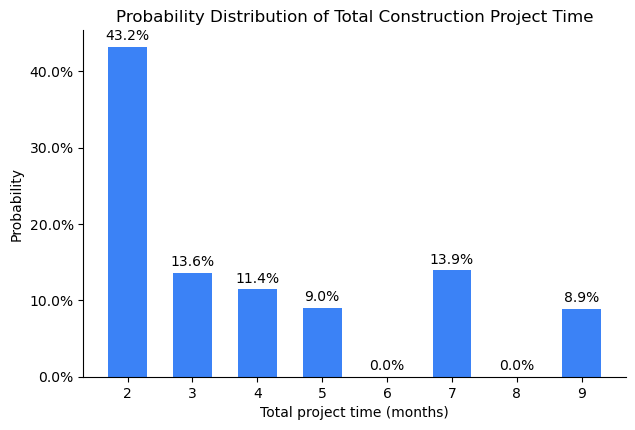

In [6]:
from matplotlib.ticker import PercentFormatter

print(f"Fastest project: {min(total_months_list)} months")
print(f"Slowest project: {max(total_months_list)} months")

months_range = range(min(total_months_list), max(total_months_list) + 1)
counts = [total_months_list.count(m) for m in months_range]
probs = [c / num_simulations for c in counts]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar([str(m) for m in months_range], probs, color="#3B82F6", width=0.6)

for bar, prob in zip(bars, probs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{prob:.1%}",
        ha="center",
        va="bottom",
    )

ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_xlabel("Total project time (months)")
ax.set_ylabel("Probability")
ax.set_title("Probability Distribution of Total Construction Project Time")
ax.spines[["top", "right"]].set_visible(False)

plt.show()